Biblioteki i importy:


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin


Wczytanie uprzednio przygotowanej bazy oraz klasy związków przygotowanych do analizy:


In [8]:

df = pd.read_excel('./deskryptory_z_cas_2.xlsx')
df_klasy = pd.read_excel('./Klasy_FR.xlsx')
df_klasy.set_index("cas", inplace=True)

df.set_index(df.columns[0], inplace=True)

X = df.select_dtypes(include=[np.number]).dropna()


Przygotowanie danych składa się na usunieciu kolumn z niską wariancją oraz wysoko skolerowanych kolumn jako zmniejszenie tej samej inforamcji. Po przygotowaniu tabeli, można ją ustandaryzować orac wyliczyć na jej podstawie PCA:

W skleanr nie ma gotowego rozwiązania na pozbycie się kolumn z daną korelacją, więc należy samemu przygotować taką klase:


In [9]:
class CorrelationThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.columns_to_drop_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        corr_matrix = df.corr().abs()
        
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        self.columns_to_drop_ = [column for column in upper_tri.columns if any(upper_tri[column] > self.threshold)]
        return self

    def transform(self, X):
        df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        df_dropped = df.drop(columns=self.columns_to_drop_)
        
        return df_dropped if isinstance(X, pd.DataFrame) else df_dropped.values

Pipline z wszytskimi krokami:

In [10]:

pipeline = Pipeline([
    ('drop_low_variance', VarianceThreshold(threshold=0.01)), 
    ('drop_high_correlation', CorrelationThreshold(threshold=0.95)), 
    ('scaler', StandardScaler()),                                  
    ('pca', PCA())
])

Przygotowanie wykresu głównych składowych i skumulowanej wyjaśnianej wariancji
Jako iż 4 PC wyjaśniają zadowalającą ilość wariancji tj. >60%, przyjeliśmy, że taka ilość tych składowych wystarczy do dalszej analizy.

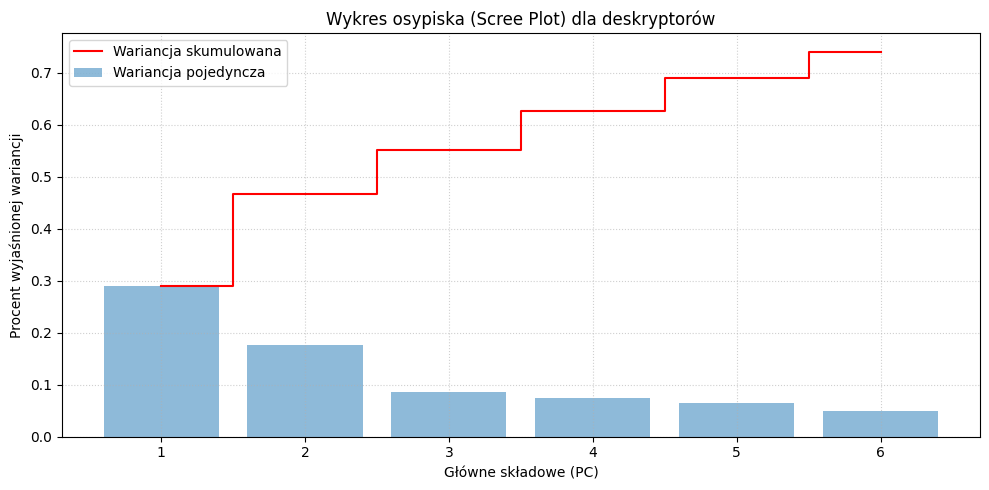

In [11]:

X_pca = pipeline.fit_transform(X)
fitted_pca = pipeline.named_steps["pca"]

explained_variance = fitted_pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.bar(range(1,7), explained_variance[:6], alpha=0.5, align='center', label='Wariancja pojedyncza')
plt.step(range(1,7), cumulative_variance[:6], where='mid', label='Wariancja skumulowana', color='red')
plt.ylabel('Procent wyjaśnionej wariancji')
plt.xlabel('Główne składowe (PC)')
plt.title('Wykres osypiska (Scree Plot) dla deskryptorów')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Wykres przedstawiający rozmieszczenie związków na poszczególnych głównych składowych, kolory tych związków odpowiadają klasom z wcześniej wczytanej bazy.

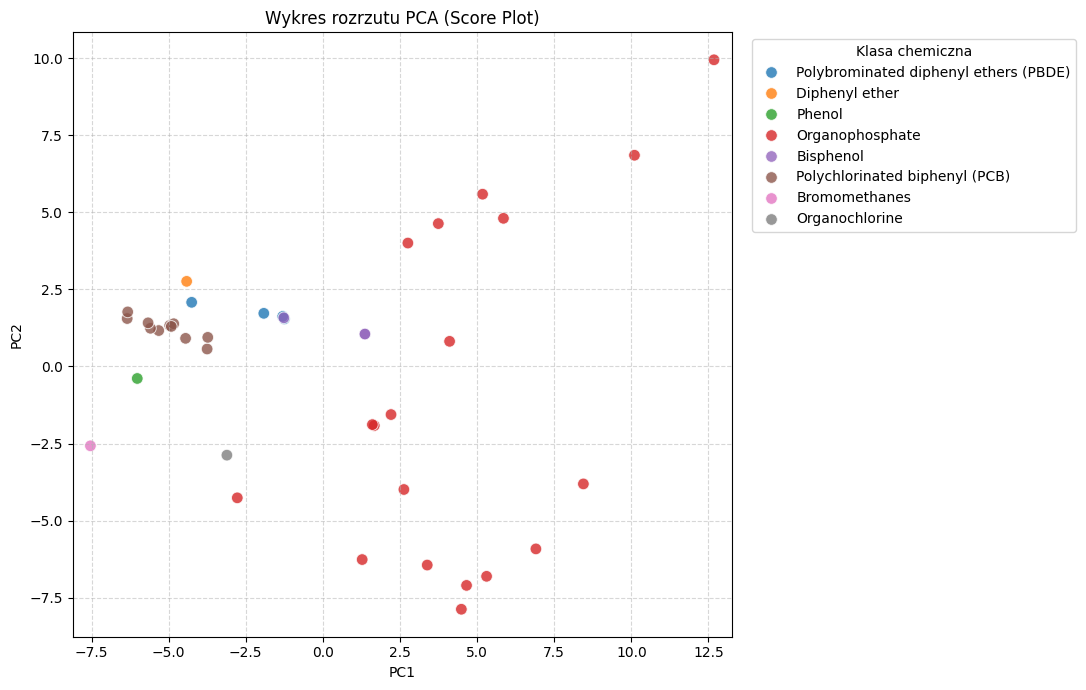

In [12]:

pca_df = pd.DataFrame(data=X_pca[:, :4], columns=['PC1', 'PC2','PC3','PC4'], index=X.index)
pca_df["klasa_chemiczna"] = pca_df.index.map(df_klasy["klasa_chemiczna"])

x_var = "PC1"
y_var = "PC2"

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_df,
    x=x_var,
    y=y_var,
    hue="klasa_chemiczna",
    palette="tab10",
    alpha=0.8,
    edgecolor="w",
    s=70,
)

plt.title("Wykres rozrzutu PCA (Score Plot)")
plt.xlabel(f"{x_var}")
plt.ylabel(f"{y_var}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Klasa chemiczna")


plt.axis('equal') 
plt.tight_layout()
plt.show()